In [334]:
# importing the needed libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import math

# Importing the Dataset

In [336]:
# reading the dataset
df_emp = pd.read_csv("HR_enhanced.csv")
df_emp.head(3)

,Employee ID,First Name,Last Name,Gender,State,City,Job Title,Education Level,Birth Date,Hire Date,...,Department,promotion_last_5years,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,Termination Date
0,E10000,Aaron,Soto,Female,Florida,Tampa,Sales Representative,Bachelor's,24-08-1984,25-07-2021,...,sales,0,0.38,0.53,2,157,3,0,1,NaN
1,E10001,Bruce,Estrada,Female,Illinois,Naperville,Sales Director,Master's,30-04-1985,28-08-2019,...,sales,0,0.80,0.86,5,262,6,0,1,NaN
2,E10002,Linda,Wells,Male,Illinois,Springfield,Sales Director,Master's,03-02-1972,29-10-2019,...,sales,0,0.11,0.88,7,272,4,0,1,NaN


In [337]:
pd.set_option('display.max_rows', 20)

In [338]:
df_emp.columns

Index(['Employee ID', 'First Name', 'Last Name', 'Gender', 'State', 'City',
       'Job Title', 'Education Level', 'Birth Date', 'Hire Date', 'salary',
       'Actual Salary', 'Department', 'promotion_last_5years',
       'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'Termination Date'],
      dtype='object')

In [339]:
# Lets check for any duplicated rows in the dataset
df_emp.duplicated().sum()

0

In [340]:
df_emp[df_emp.duplicated()]

,Employee ID,First Name,Last Name,Gender,State,City,Job Title,Education Level,Birth Date,Hire Date,...,Department,promotion_last_5years,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,Termination Date


In [341]:
df_emp.shape

(14999, 22)

# Understanding the Dataset

Termination date has null values because most of the employees are still working for the company.

In [344]:
df_emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee ID            14999 non-null  object 
 1   First Name             14999 non-null  object 
 2   Last Name              14999 non-null  object 
 3   Gender                 14999 non-null  object 
 4   State                  14999 non-null  object 
 5   City                   14999 non-null  object 
 6   Job Title              14999 non-null  object 
 7   Education Level        14999 non-null  object 
 8   Birth Date             14999 non-null  object 
 9   Hire Date              14999 non-null  object 
 10  salary                 14999 non-null  object 
 11  Actual Salary          14999 non-null  int64  
 12  Department             14999 non-null  object 
 13  promotion_last_5years  14999 non-null  int64  
 14  satisfaction_level     14999 non-null  float64
 15  la

In [345]:

df_emp['Birth Date'] = pd.to_datetime(df_emp['Birth Date'], format='%d-%m-%Y', errors='coerce')
df_emp['Termination Date '] = pd.to_datetime(df_emp['Termination Date'], format='%d-%m-%Y', errors='coerce')
df_emp['Hire Date'] = pd.to_datetime(df_emp['Hire Date'], format='%d-%m-%Y', errors='coerce')


In [346]:
df_emp.rename(columns={'salary':'Salary Category'},inplace=True)

In [347]:
df_emp['Birth Date']

0       1984-08-24
1       1985-04-30
2       1972-02-03
3       1967-10-17
4       1980-04-10
           ...    
14994   1970-12-29
14995   1978-10-13
14996   1981-06-25
14997   1997-08-11
14998   1997-08-25
Name: Birth Date, Length: 14999, dtype: datetime64[ns]

In [348]:
df_emp['Department'].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [349]:
# promation in last five years
df_emp['promotion_last_5years'].value_counts()

promotion_last_5years
0    14680
1      319
Name: count, dtype: int64

In [350]:
# different data types count
df_emp.dtypes.value_counts()

object            11
int64              7
datetime64[ns]     3
float64            2
Name: count, dtype: int64

## 1. Checking the data quality

In [352]:
df_emp.isna().sum(axis = 0)

Employee ID               0
First Name                0
Last Name                 0
Gender                    0
State                     0
                      ...  
time_spend_company        0
Work_accident             0
left                      0
Termination Date      13315
Termination Date      13315
Length: 23, dtype: int64

# Performing EDA

## 1. Performing EDA to find out what factors contributed the most to employee turnover.

In [355]:
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"


In [356]:
df_emp.columns

Index(['Employee ID', 'First Name', 'Last Name', 'Gender', 'State', 'City',
       'Job Title', 'Education Level', 'Birth Date', 'Hire Date',
       'Salary Category', 'Actual Salary', 'Department',
       'promotion_last_5years', 'satisfaction_level', 'last_evaluation',
       'number_project', 'average_montly_hours', 'time_spend_company',
       'Work_accident', 'left', 'Termination Date', 'Termination Date '],
      dtype='object')

In [357]:
# separating columns according to datatypes to conduct univariate analysis
numeric_cols = df_emp.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_cols = df_emp.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df_emp.select_dtypes(include=['datetime64']).columns.tolist()
print("Numeric Columns:", numeric_cols)
print("Object Columns:", object_cols)
print("datetime Columns",datetime_cols)

Numeric Columns: ['Actual Salary', 'promotion_last_5years', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left']
Object Columns: ['Employee ID', 'First Name', 'Last Name', 'Gender', 'State', 'City', 'Job Title', 'Education Level', 'Salary Category', 'Department', 'Termination Date']
datetime Columns ['Birth Date', 'Hire Date', 'Termination Date ']


### Univariate analysis on numeric data

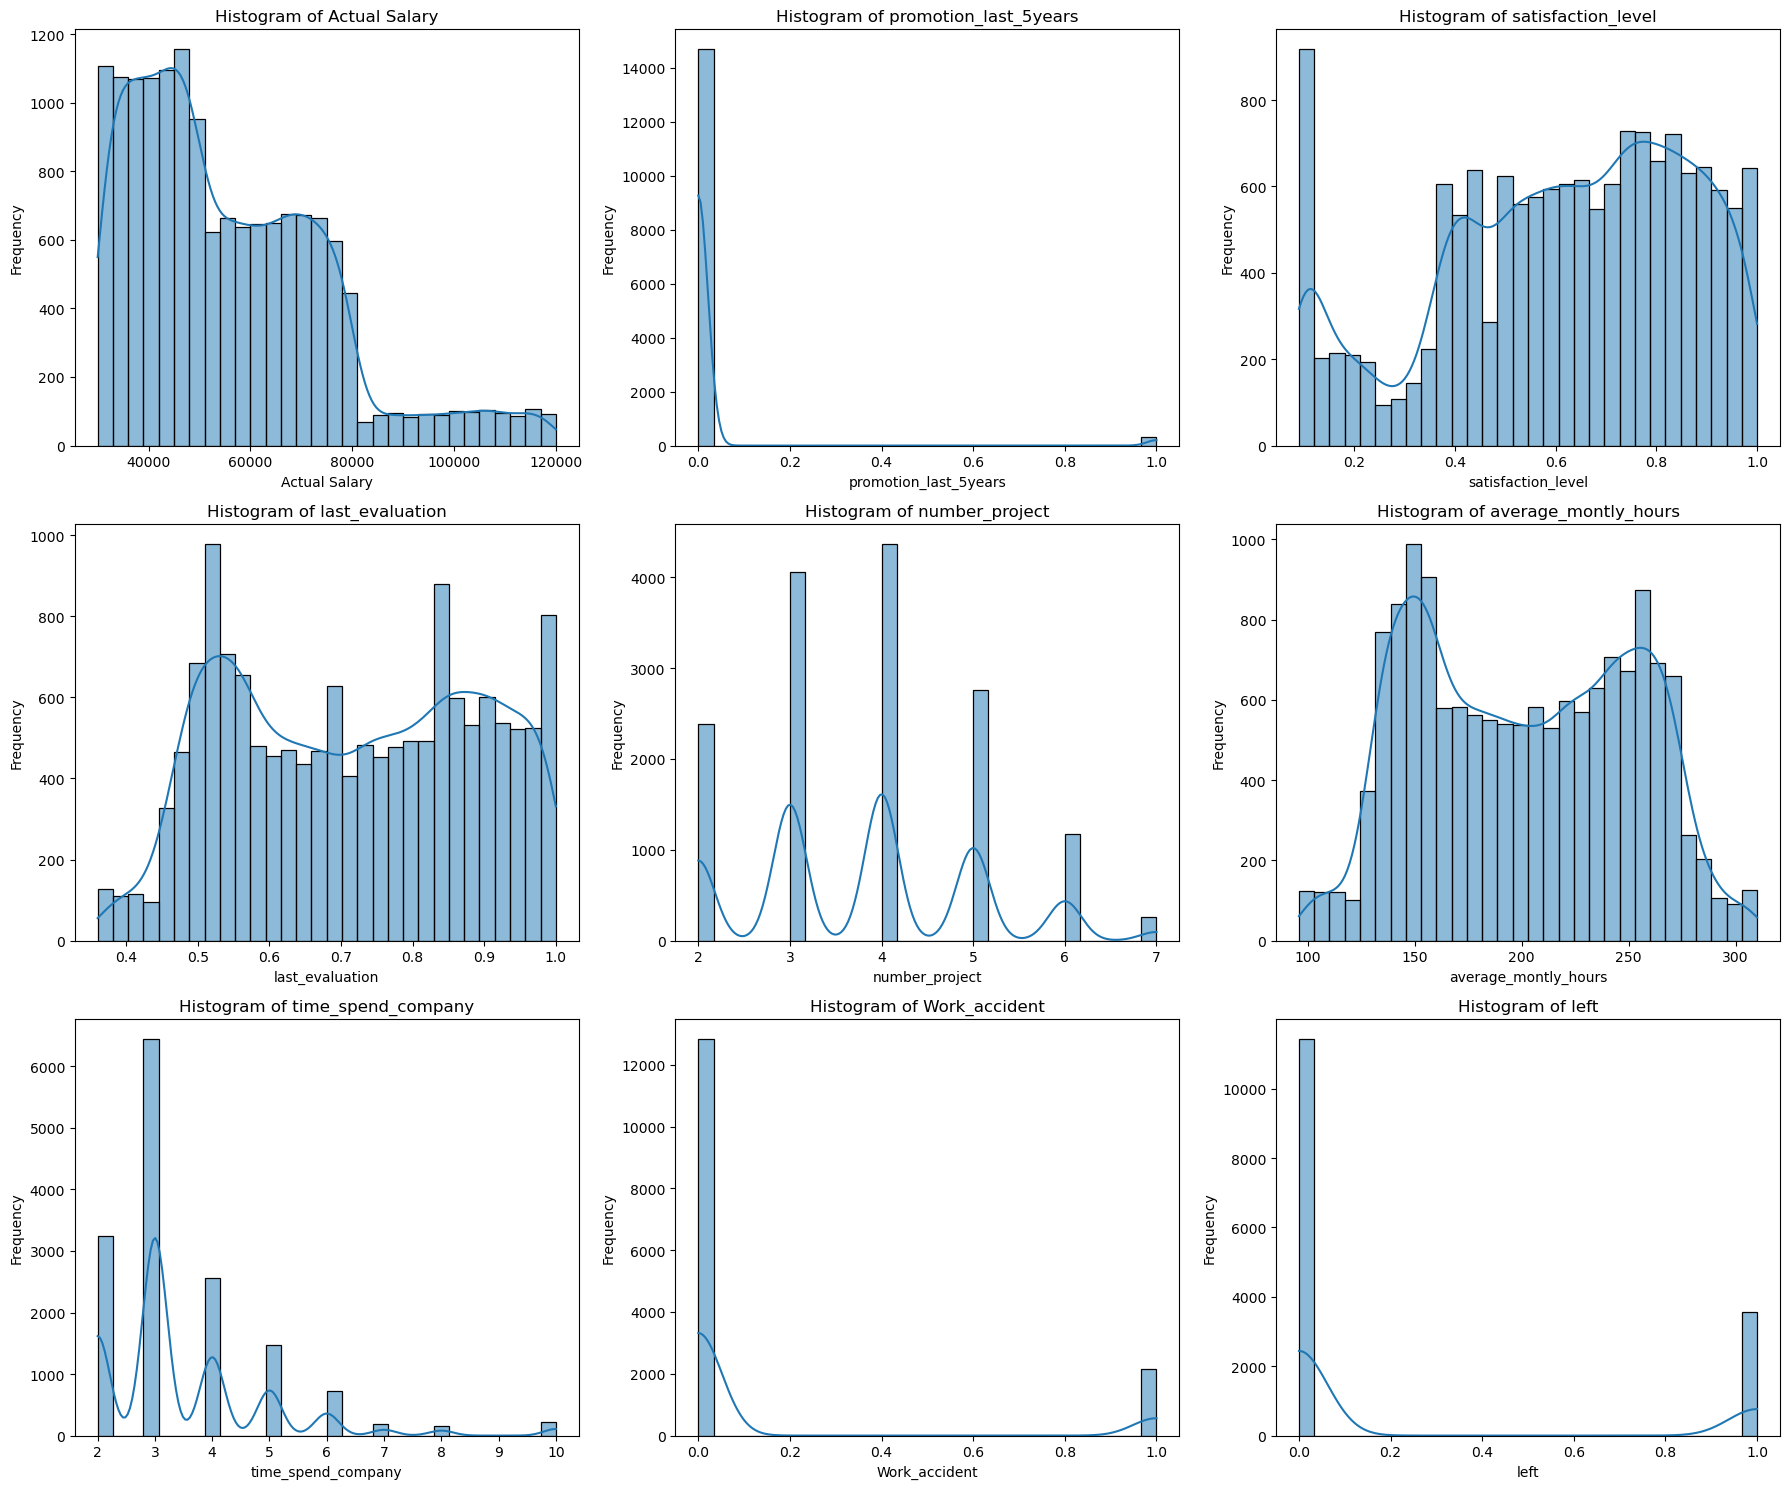

In [359]:
# Univariate analysis on numeric data

import math
n = len(numeric_cols)
n_cols = 3  # 3 plots per row
n_rows = math.ceil(n / n_cols)  # total rows needed

# Create subplot grid 
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()  

# --- Loop through numeric columns and plot ---
for i, col in enumerate(numeric_cols):
    sns.histplot(df_emp[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# # --- Turn off unused plots (if any) ---
# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

plt.tight_layout()
plt.show()

Observations from univariate analysis:
1. Most of the employees salary are in range between 20000 to 80000 . Too few are getting high salary.
2. Too less got promotions in last five years.
3. Large no. of employees gave satisfaction rating above 0-5 but significant no.of employees also gave least rating .
4. Most of the employees have done 3-5 projects projects.
5. Most of the employees work for around 200 hours in a month on an average. Meaning 6-7 hours a day.
6. Most of the employees spent 3-4 years in this company. 
7. There are less number of accident reported.

In [361]:
object_cols

['Employee ID',
 'First Name',
 'Last Name',
 'Gender',
 'State',
 'City',
 'Job Title',
 'Education Level',
 'Salary Category',
 'Department',
 'Termination Date']

### Univariate analysis on categorical data

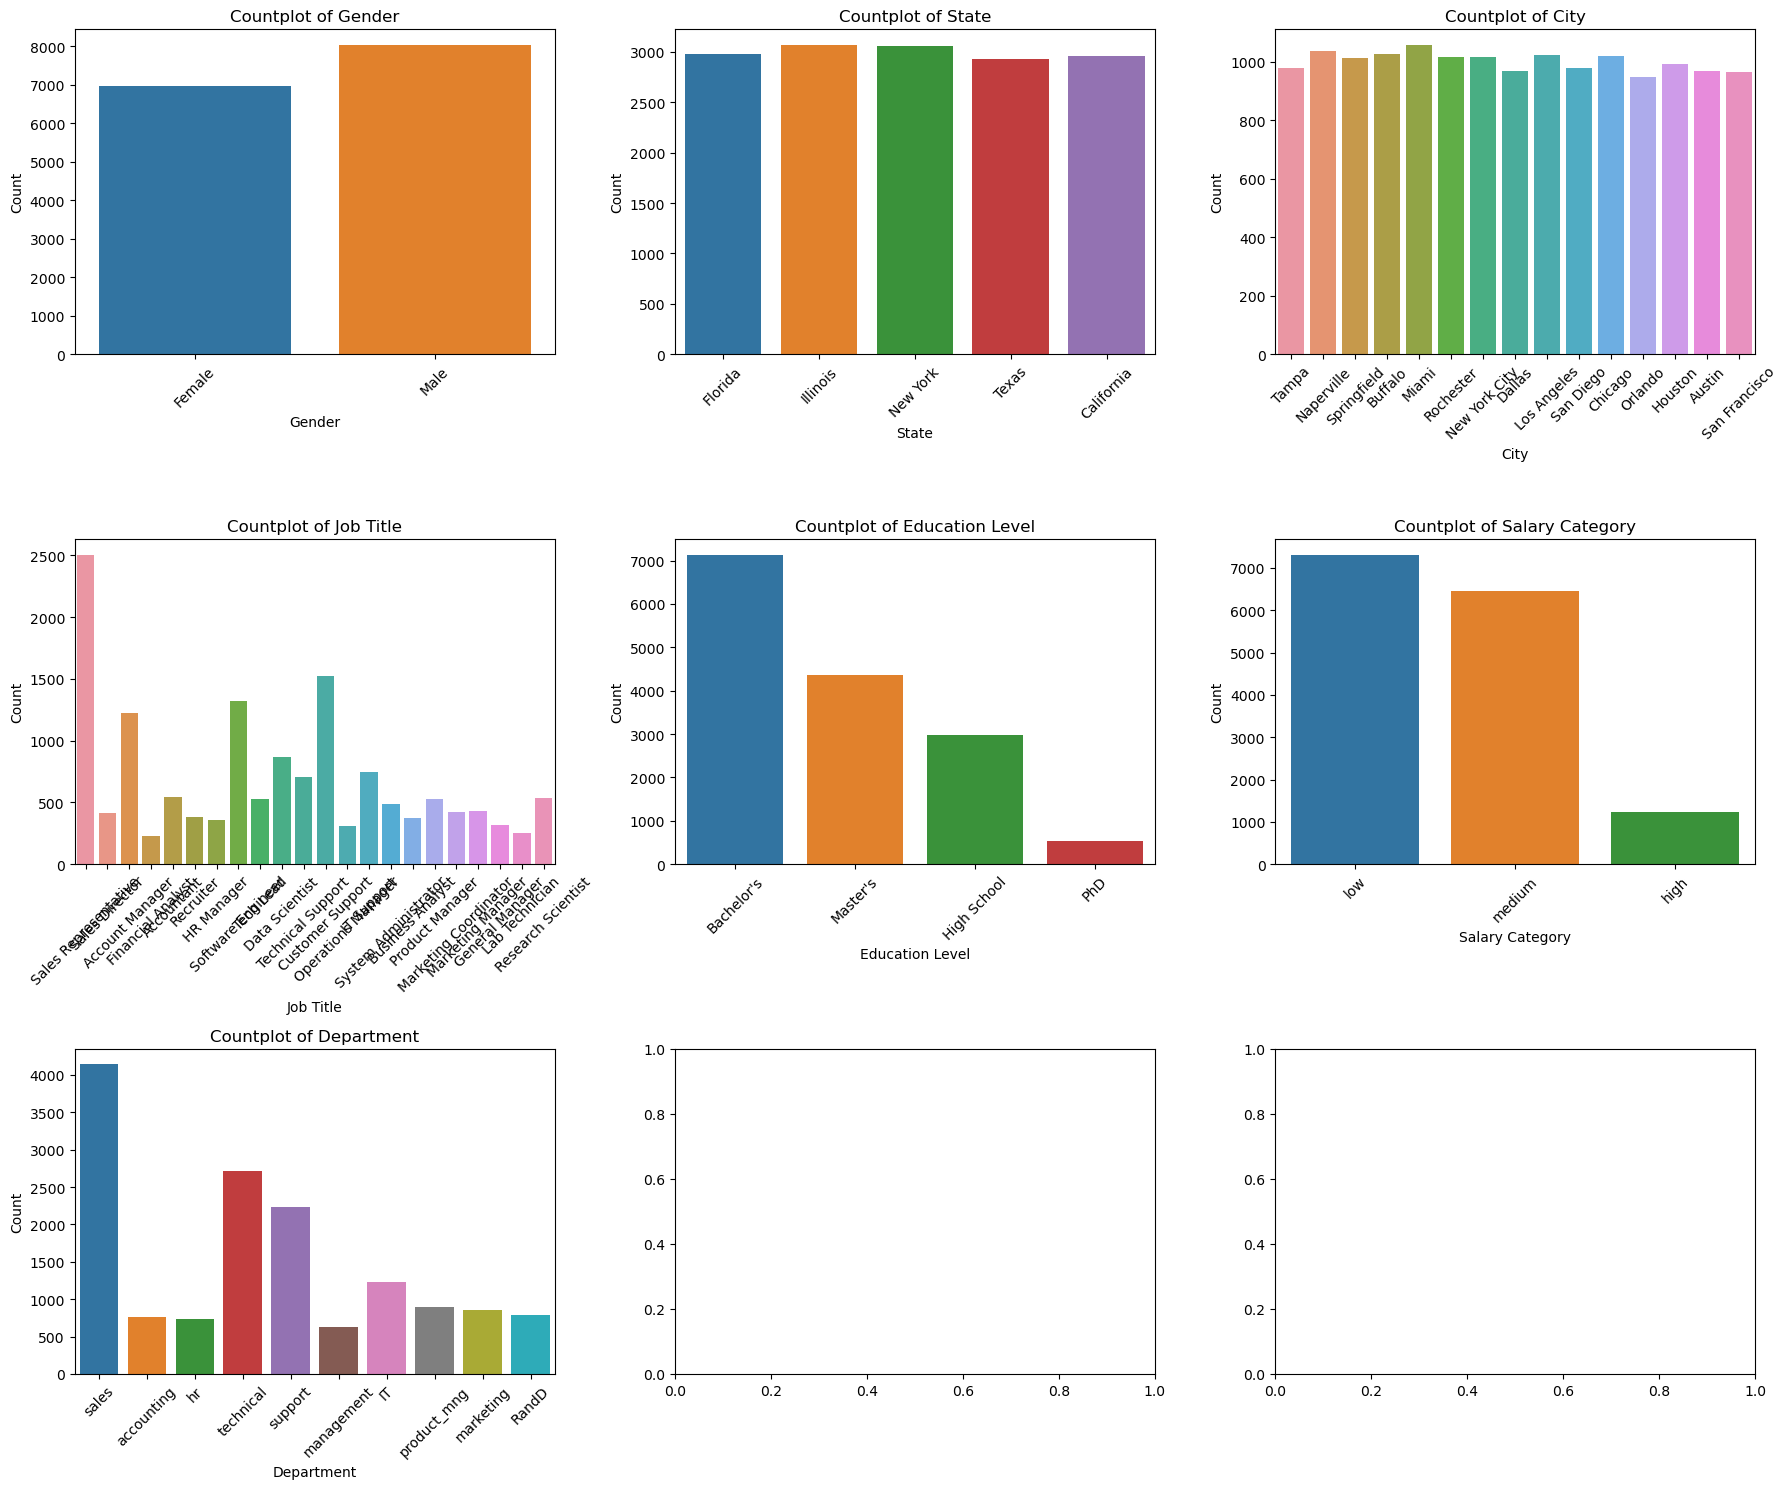

In [363]:
# Univariate analysis on categorical data

obj_include = ['Gender',
 'State',
 'City',
 'Job Title',
 'Education Level',
 'Salary Category',
 'Department']   # categorical columens to be included for the univariate analysis
n = len(obj_include)
n_col = 3
n_row = math.ceil(n/n_col)

fig,axs = plt.subplots(nrows=n_row, ncols=n_col, figsize=(18, 5 * n_rows))
axs = axs.flatten()
for i , col in enumerate(obj_include):
    sns.countplot(x=df_emp[col],ax = axs[i])
    axs[i].set_title(f"Countplot of {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Count")
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Important Observations :
1. Sales Representative role and Sales department has large number of employees in the company.
2. Employees who have bachelors degree are large in number whereas PHD holders are few only.
3. Most of the Employees are working in low salary bracket while few are working with high salary bracket.
4. 

### Bivariate Analysis to see relationship of features with Target left column

In [366]:
# Plotting a correlation plot to get an idea for the bivariate analysis with left column.

df_emp_num = df_emp.select_dtypes(include=["number"]).corr()
df_emp_num

,Actual Salary,promotion_last_5years,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left
Actual Salary,1.000000,0.088020,0.044730,-0.011696,-0.002394,-0.004197,0.049373,0.001200,-0.147050
promotion_last_5years,0.088020,1.000000,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788
satisfaction_level,0.044730,0.025605,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375
last_evaluation,-0.011696,-0.008684,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567
number_project,-0.002394,-0.006064,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787
average_montly_hours,-0.004197,-0.003544,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287
time_spend_company,0.049373,0.067433,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822
Work_accident,0.001200,0.039245,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622
left,-0.147050,-0.061788,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000


Important features to consider for bivariate analysis are : Actual Salary , promotion_last_5years , satisfaction_level , Work_accident , average_montly_hours , time_spend_company	

From the correlation matrix it is seen that last_evalustion, number_project , average_monthly_hours has a relation with each other . and time_spend in a country is directly related to our target variable.

In [369]:
df_emp["Department"].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [370]:
df_emp['left'] = df_emp['left'].astype(str)

In [371]:
# to get department wise attrition
df_1 = df_emp.groupby(["Department"])['left'].value_counts().reset_index(name = "Count")

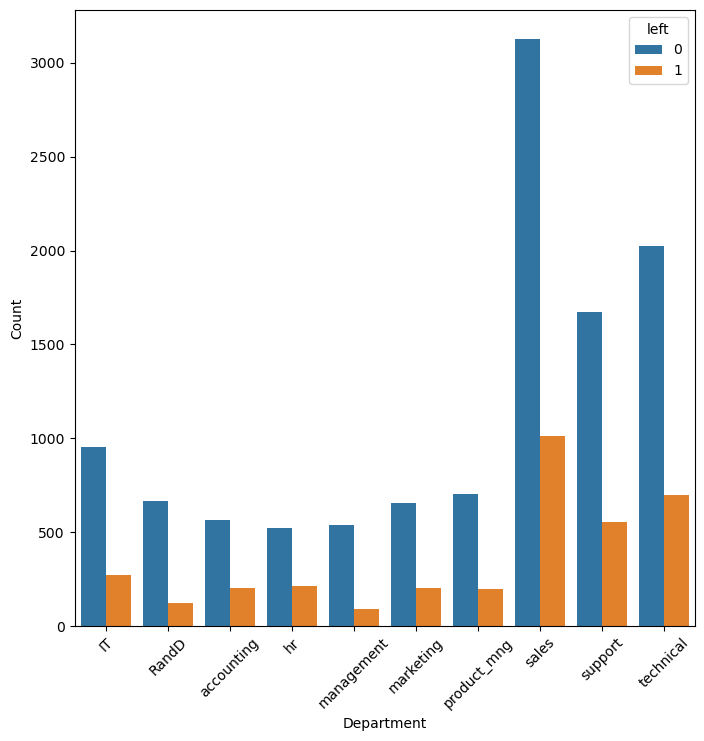

In [372]:
# plot department wise attrition
plt.figure(figsize=(8,8))
sns.barplot(x = 'Department',y = 'Count',hue = 'left',data=df_1 )
plt.xticks(rotation=45)
plt.show()

By looking at the graph above the most attrition happened in sales , support , technical then IT and least happend in HR

In [374]:
df_2 = df_emp["Department"].value_counts().reset_index(name = "Total")
# df_2.columns=['Department','Total']
df_2

,Department,Total
0,sales,4140
1,technical,2720
2,support,2229
3,IT,1227
4,product_mng,902
5,marketing,858
6,RandD,787
7,accounting,767
8,hr,739
9,management,630


In [375]:
# merging the two df to visualize attrition department wise
df_merge = df_1.merge(df_2,how = "left")
df_merge

,Department,left,Count,Total
0,IT,0,954,1227
1,IT,1,273,1227
2,RandD,0,666,787
3,RandD,1,121,787
4,accounting,0,563,767
5,accounting,1,204,767
6,hr,0,524,739
7,hr,1,215,739
8,management,0,539,630
9,management,1,91,630


In [376]:
df_merge['per_of_total'] = df_merge['Count']/df_merge['Total']
df_merge['per_of_total'] = round(df_merge['per_of_total'] * 100,2)
df_merge

,Department,left,Count,Total,per_of_total
0,IT,0,954,1227,77.75
1,IT,1,273,1227,22.25
2,RandD,0,666,787,84.63
3,RandD,1,121,787,15.37
4,accounting,0,563,767,73.40
5,accounting,1,204,767,26.60
6,hr,0,524,739,70.91
7,hr,1,215,739,29.09
8,management,0,539,630,85.56
9,management,1,91,630,14.44


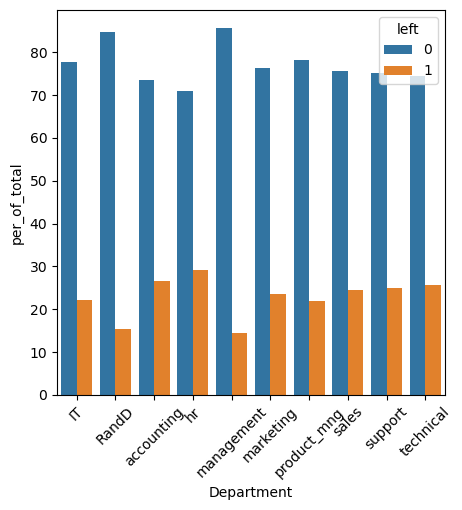

In [377]:
plt.figure(figsize=(5,5)) # 1 means left 
sns.barplot(x='Department',y='per_of_total',hue='left',data=df_merge)
plt.xticks(rotation=45)
plt.show()

According to the above graph HR dept has the most no.of employees who left among all the departments.

In [379]:
df_emp.columns

Index(['Employee ID', 'First Name', 'Last Name', 'Gender', 'State', 'City',
       'Job Title', 'Education Level', 'Birth Date', 'Hire Date',
       'Salary Category', 'Actual Salary', 'Department',
       'promotion_last_5years', 'satisfaction_level', 'last_evaluation',
       'number_project', 'average_montly_hours', 'time_spend_company',
       'Work_accident', 'left', 'Termination Date', 'Termination Date '],
      dtype='object')

<Axes: xlabel='satisfaction_level', ylabel='Count'>

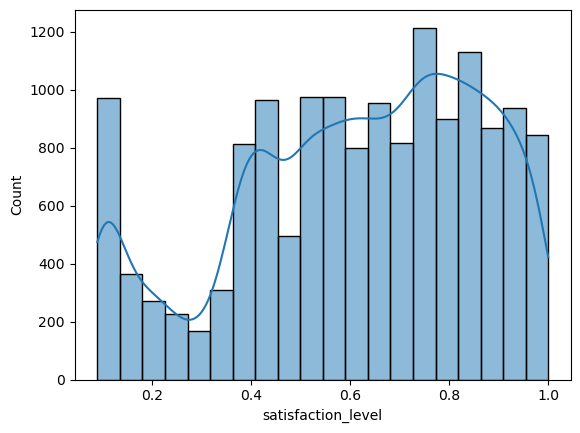

In [380]:
# to plot trend in satisfaction level 
sns.histplot(data = df_emp , x = 'satisfaction_level' , kde = True , bins = 20)

It can be inferred that most employees are satisfied

<Axes: xlabel='average_montly_hours', ylabel='Count'>

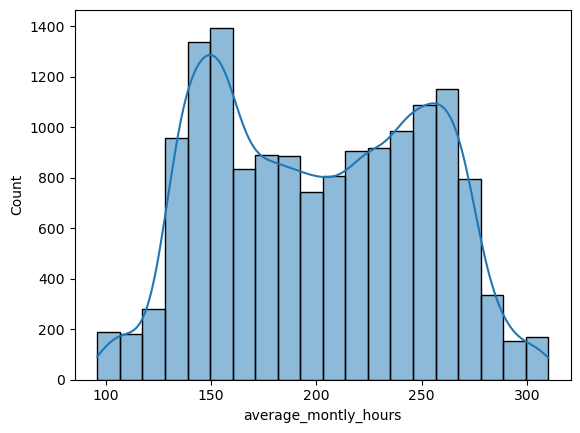

In [382]:
# to see trends in hourly working in a month
sns.histplot(data=df_emp,x='average_montly_hours',kde=True,bins=20)

In [383]:
df_sal = df_emp.groupby(['Salary Category'])['left'].value_counts().reset_index(name = "count")
df_sal


,Salary Category,left,count
0,high,0,1155
1,high,1,82
2,low,0,5144
3,low,1,2172
4,medium,0,5129
5,medium,1,1317


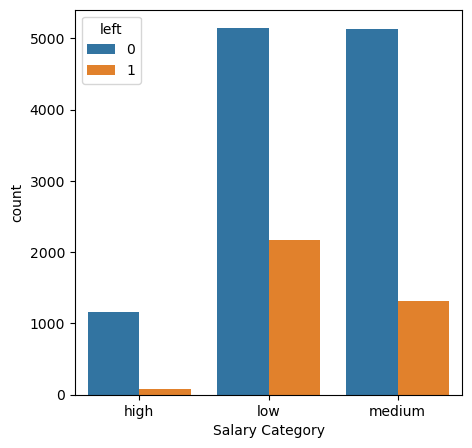

In [384]:
# barplot to see impact of salary on attrition
plt.figure(figsize=(5,5))
sns.barplot(x = 'Salary Category',y = 'count',hue = 'left', data = df_sal)
plt.show()

Low salary is one of the main reason to leave the job.

In [386]:
df_prom = df_emp.groupby(['promotion_last_5years'])['left'].value_counts().reset_index(name="count")
df_prom

,promotion_last_5years,left,count
0,0,0,11128
1,0,1,3552
2,1,0,300
3,1,1,19


<Axes: xlabel='promotion_last_5years', ylabel='count'>

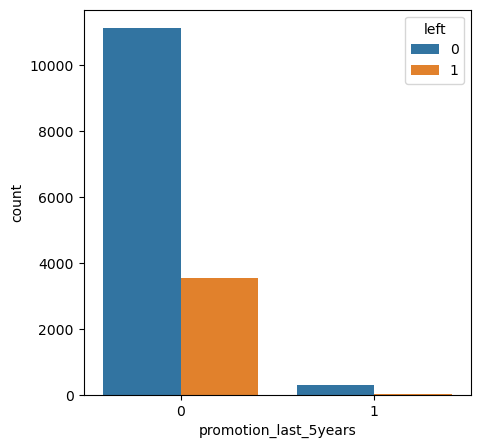

In [387]:
plt.figure(figsize=(5,5))
sns.barplot(x = 'promotion_last_5years',y ='count',hue = 'left',data = df_prom)

Those who are not promoted had left in large numbers,

In [389]:
df_time = df_emp.groupby(["time_spend_company"])["left"].value_counts().reset_index()
df_time

,time_spend_company,left,count
0,2,0,3191
1,2,1,53
2,3,0,4857
3,3,1,1586
4,4,0,1667
5,4,1,890
6,5,1,833
7,5,0,640
8,6,0,509
9,6,1,209


<Axes: xlabel='time_spend_company', ylabel='count'>

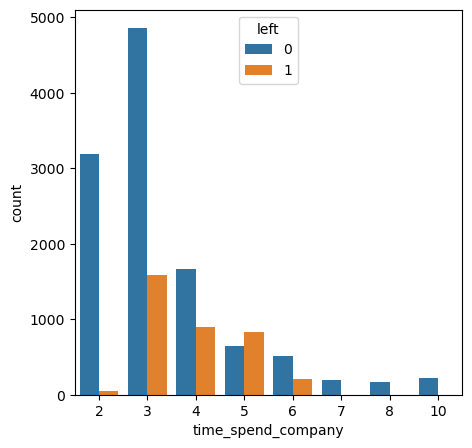

In [390]:
# visualising relation between time spent and attrition
plt.figure(figsize=(5,5))
sns.barplot(x = "time_spend_company",y = 'count', hue = 'left',data = df_time)

employees with 3 years of experience left mostly.

### Multivariate Analysis

In [393]:
# to see relationship between features and check multicolinearity
df_emp.columns

Index(['Employee ID', 'First Name', 'Last Name', 'Gender', 'State', 'City',
       'Job Title', 'Education Level', 'Birth Date', 'Hire Date',
       'Salary Category', 'Actual Salary', 'Department',
       'promotion_last_5years', 'satisfaction_level', 'last_evaluation',
       'number_project', 'average_montly_hours', 'time_spend_company',
       'Work_accident', 'left', 'Termination Date', 'Termination Date '],
      dtype='object')

In [394]:
corr1=df_emp[[ 'Actual Salary', 
       'promotion_last_5years', 'satisfaction_level', 'last_evaluation',
       'number_project', 'average_montly_hours', 'time_spend_company',
       'Work_accident','left']].corr()

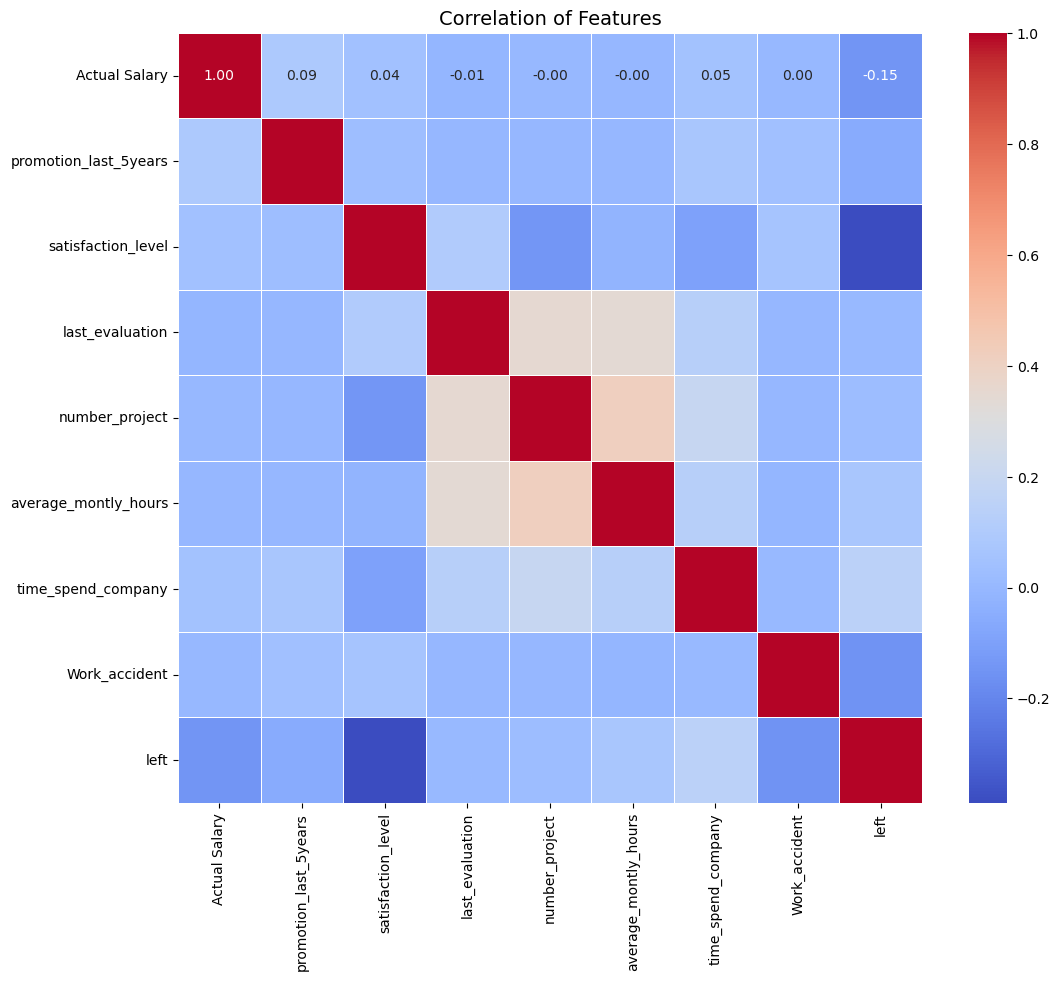

In [331]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation of Features", fontsize=14)
plt.show()

Features which are directly related with each other are :, last_evaluation , number_project , average_monthly_hours
Features which are inversely related witg each other are : left (target column) , satisfaction_level , Actual salary , work_accidents

## Sol 3. Performing clustering of employees based on satisfaction level and last_evaluation.

Let's first try to find out the number of clusters in which employees can be grouped well according to dataset. For doing this elbow method is used .

In [395]:
from sklearn.cluster import KMeans

In [396]:
# To find no.of clusters 

wcss = []
for i in range(1,21):
    km = KMeans(n_clusters = i)
    km.fit_predict(df_clus)
    wcss.append(km.inertia_)

array([0, 0, 0, ..., 0, 0, 0])

array([0, 0, 0, ..., 0, 0, 0])

array([1, 1, 1, ..., 1, 1, 1])

array([1, 3, 1, ..., 1, 1, 1])

array([1, 3, 1, ..., 1, 1, 1])

...

array([5, 3, 1, ..., 5, 1, 5])

array([3, 1, 2, ..., 3, 2, 3])

array([0, 2, 5, ..., 0, 5, 0])

array([2, 0, 4, ..., 2, 4, 2])

array([2, 4, 0, ..., 2, 0, 2])

In [397]:
wcss # with more clusters wcss decreases

[4087.3659978665246,
 1226.6953610234118,
 867.9608255983076,
 634.4842007722743,
 492.1635126848172,
 364.4735774418636,
 275.0826151987251,
 207.5983762036334,
 179.20465404545342,
 158.14658352584297,
 141.08704537780557,
 127.66231220594308,
 116.3571913316843,
 107.355993535501,
 101.59775480248744,
 96.96881355258576,
 91.3896389790033,
 87.29430713869247,
 82.54491888119125,
 78.6679088487748]

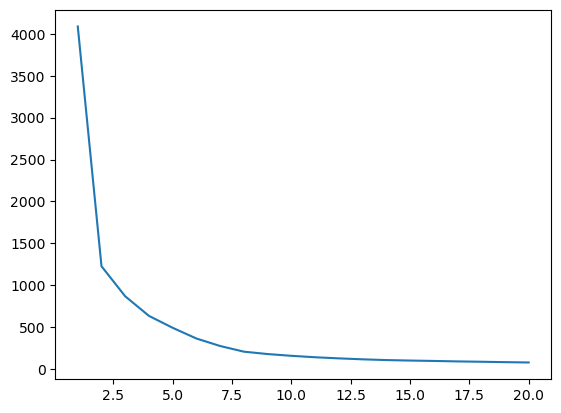

In [398]:
# employing the elbow method to find correct number of clusters by plotting wcss on y and nu. of clusters on x.
plt.plot(range(1,21),wcss)

So here we find that number of clusters should be 7 or 8 since at these the rate of change in slope decreases. But lets try with 6 clusters.

In [400]:
km = df_clus.iloc[:,:].values
km

array([[0.38, 0.53, '1'],
       [0.8, 0.86, '1'],
       [0.11, 0.88, '1'],
       ...,
       [0.37, 0.53, '1'],
       [0.11, 0.96, '1'],
       [0.37, 0.52, '1']], dtype=object)

In [401]:
from sklearn.cluster import KMeans
km = df_clus.iloc[:,:].values
kmeans = KMeans(n_clusters = 3,random_state = 0)
y_means = kmeans.fit_predict(km)

In [402]:
y_means

array([1, 1, 1, ..., 1, 1, 1])

We have tried with different number of clusters and finally taken 3 to classify employees into different groups based on their evaluation and satisfaction level . one can take 4 also.

In [404]:
km[y_means == 1,0], km[y_means == 1,1] # cluster 1 x coordinates and y coordinates

(array([0.38, 0.8, 0.11, ..., 0.37, 0.11, 0.37], dtype=object),
 array([0.53, 0.86, 0.88, ..., 0.53, 0.96, 0.52], dtype=object))

<Figure size 500x500 with 0 Axes>

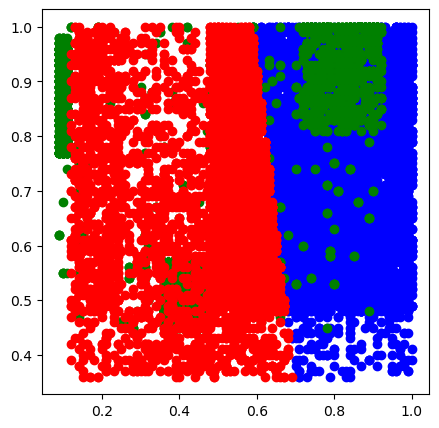

In [405]:
plt.figure(figsize=(5,5))
plt.scatter(km[y_means==0,0],km[y_means==0,1],color = 'blue')
plt.scatter(km[y_means==1,0],km[y_means==1,1],color = 'green')
plt.scatter(km[y_means==2,0],km[y_means==2,1],color = 'red')
# plt.scatter(km[y_means==3,0],km[y_means==3,1],color = 'black')
plt.show()

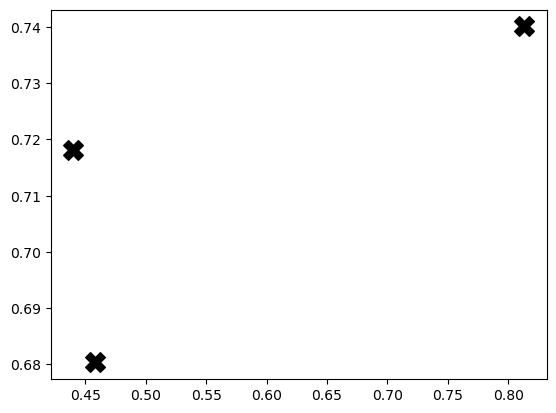

In [406]:
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, color="black", marker="X", label="Centroids")

y axis showing last evaluation and x axis showing the satisfaction level
the blue represents the employees with best satisfaction level and they scored high in last evaluation. thegreend represent the employees with medium satisfaction and scored high in the last evaluation.# thredow represents the employees with lower satisfaction with less scoresin the last evaluation.

In [408]:
df_emp['left'] = df_emp['left'].astype('int64')

In [409]:
df_emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Employee ID            14999 non-null  object        
 1   First Name             14999 non-null  object        
 2   Last Name              14999 non-null  object        
 3   Gender                 14999 non-null  object        
 4   State                  14999 non-null  object        
 5   City                   14999 non-null  object        
 6   Job Title              14999 non-null  object        
 7   Education Level        14999 non-null  object        
 8   Birth Date             14999 non-null  object        
 9   Hire Date              14999 non-null  object        
 10  salary                 14999 non-null  object        
 11  Actual Salary          14999 non-null  int64         
 12  Department             14999 non-null  object        
 13  p

In [410]:
df_emp_numerical = df_emp.select_dtypes(include=['int64','float64'])
df_emp_categorical = df_emp.select_dtypes(include = ['object'])
df_emp_categorical = df_emp_categorical[['Gender','salary','Department']]

from all categorical columns only gender , salary and Department woth important to predict attrition

# Data Preparation for the model training

In [413]:
df_emp_cat = pd.get_dummies(data = df_emp_categorical)
df_emp_cat

,Gender_Female,Gender_Male,salary_high,salary_low,salary_medium,Department_IT,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False
3,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False
4,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False
14995,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False
14996,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False
14997,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False


In [414]:
df_emp_final = pd.concat([df_emp_numerical,df_emp_cat],axis = 1,join = 'inner')
df_emp_final.shape

(14999, 24)

In [415]:
# separating target and data variables

x = df_emp_final.drop('left',axis = 1)
y = df_emp_final["left"]
y

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: int64

In [416]:
df_emp_final.columns
x.columns

Index(['Actual Salary', 'promotion_last_5years', 'satisfaction_level',
       'last_evaluation', 'number_project', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'Gender_Female',
       'Gender_Male', 'salary_high', 'salary_low', 'salary_medium',
       'Department_IT', 'Department_RandD', 'Department_accounting',
       'Department_hr', 'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')

Index(['Actual Salary', 'promotion_last_5years', 'satisfaction_level',
       'last_evaluation', 'number_project', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'Gender_Female', 'Gender_Male',
       'salary_high', 'salary_low', 'salary_medium', 'Department_IT',
       'Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')

In [417]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((11999, 23), (3000, 23), (11999,), (3000,))

In [418]:
y_train.value_counts()

left
0    9134
1    2865
Name: count, dtype: int64

By looking at the value counts it is seen that the dataset is highly imbalanced . So we need to balance it to get unbiased results. Hence we are using SMOTE Technique to balanced the dataset.

## Sol 4. Handle the left Class Imbalance using SMOTE technique

In [421]:
import imblearn
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 2)

In [422]:
x_trains,y_trains = sm.fit_resample(x_train,y_train)
x_tests,y_tests = sm.fit_resample(x_test,y_test)

In [423]:
y_trains.value_counts()

left
0    9134
1    9134
Name: count, dtype: int64

## Sol 5.Perform k-fold cross-validation model training and evaluate performance

In [425]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics

In [426]:
# training the model logistic regression
logreg = LogisticRegression(solver='lbfgs',max_iter=1000)
print(cross_val_score(logreg,x_trains,y_trains,cv = 5 , error_score = "raise"))
print(cross_val_score(logreg,x_trains,y_trains,cv = 5 , error_score = "raise").mean())

[0.55528188 0.55582923 0.54734537 0.56720504 0.80755543]
0.6066433913777146


In [427]:
# testing 
logreg.fit(x_trains,y_trains)
y_pred = logreg.predict(x_tests)
y_pred

LogisticRegression(max_iter=1000)

array([0, 1, 1, ..., 1, 0, 1], dtype=int64)

In [428]:
from sklearn.metrics import classification_report
metrics.confusion_matrix(y_tests,y_pred)

array([[1267, 1027],
       [ 955, 1339]], dtype=int64)

In [429]:
print(classification_report(y_tests,y_pred))

              precision    recall  f1-score   support

           0       0.57      0.55      0.56      2294
           1       0.57      0.58      0.57      2294

    accuracy                           0.57      4588
   macro avg       0.57      0.57      0.57      4588
weighted avg       0.57      0.57      0.57      4588



In [430]:
roc_auc_score(y_tests,y_pred)

0.5680034873583261

In [431]:
fpr,tpr,threshold = metrics.roc_curve(y_tests,y_pred)
print(fpr)
print(tpr)
print(threshold)

roc_auc = metrics.auc(fpr,tpr)
print(roc_auc)

[0.         0.44768963 1.        ]
[0.        0.5836966 1.       ]
[2 1 0]
0.5680034873583261


## 6.Identify the best model and justify the evaluation metrics used.

In [433]:
# RandomForest
rdm = RandomForestClassifier(max_depth = 5)
print(cross_val_score(rdm,x_trains,y_trains,cv = 5).mean())

0.9180528229491293


In [434]:
rdm.fit(x_trains,y_trains)
y_pred1 = rdm.predict(x_tests)
y_pred1

RandomForestClassifier(max_depth=5)

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [435]:
fpr,tpr,threshold = metrics.roc_curve(y_tests,y_pred1)
print(fpr)
print(tpr)
print(threshold)
roc_auc = metrics.auc(fpr,tpr)
print(roc_auc)

[0.         0.05318221 1.        ]
[0.         0.84437663 1.        ]
[2 1 0]
0.8955972101133393


## Sol 7.Deciding about important features using Random Forest for suggesting Retension Strategies

In [437]:
col = x_trains.columns
col

Index(['Actual Salary', 'promotion_last_5years', 'satisfaction_level',
       'last_evaluation', 'number_project', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'Gender_Female', 'Gender_Male',
       'salary_high', 'salary_low', 'salary_medium', 'Department_IT',
       'Department_RandD', 'Department_accounting', 'Department_hr',
       'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'],
      dtype='object')

In [438]:
feature_labels = np.array(col)
feature_labels

array(['Actual Salary', 'promotion_last_5years', 'satisfaction_level',
       'last_evaluation', 'number_project', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'Gender_Female',
       'Gender_Male', 'salary_high', 'salary_low', 'salary_medium',
       'Department_IT', 'Department_RandD', 'Department_accounting',
       'Department_hr', 'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical'], dtype=object)

In [439]:
# importanct of features
importance = rdm.feature_importances_
feature_index_by_dec_imp = importance.argsort()[::-1]
for feature in feature_index_by_dec_imp :
    print('{}:{:.2f}%'.format(feature_labels[feature],importance[feature]*100))

satisfaction_level:25.82%
time_spend_company:20.24%
number_project:17.28%
average_montly_hours:11.44%
last_evaluation:8.58%
Work_accident:4.70%
Gender_Male:3.76%
Gender_Female:3.70%
Actual Salary:1.36%
Department_technical:0.75%
salary_high:0.66%
Department_sales:0.58%
salary_low:0.40%
Department_support:0.23%
Department_hr:0.13%
salary_medium:0.11%
promotion_last_5years:0.08%
Department_accounting:0.06%
Department_product_mng:0.04%
Department_marketing:0.03%
Department_management:0.02%
Department_IT:0.01%
Department_RandD:0.01%


So we find that satisfaction_level:26.57% ,
time_spend_company:19.06 , 
number_project:16.9 , %
average_montly_hours:12. , 7%
last_evaluation:
are top 5 features which are important to retain the employee . By using this insights we can make retension strategy for the employees.9.70

In [441]:
predict_prob = rdm.predict_proba(x_test)
predict_prob[:,1]

array([0.15599911, 0.10087856, 0.15108409, ..., 0.15876288, 0.3020541 ,
       0.5235375 ])

In [442]:
zone = []
prob = []
for i in predict_prob[:,1]:
    prob.append(i)
    
    if (i<=0.2):
        zone.append("safe")
    elif(i>0.2 and i<=0.6):
        zone.append("low risk")
    elif(i>0.6 and i<=0.9):
        zone.append("medium risk")
    else:
        zone.append("high risk")

In [443]:
categories =["safe","low risk","medium risk","high risk"]
color = ["green","yellow","orange","red"]
colordict = dict(zip(categories,color)) # making a dictionary by zip them corresponding to color assingned like safe : green

In [444]:
plr = pd.DataFrame({"zone":zone,"probability":prob})
plr["zone"].unique()

array(['safe', 'high risk', 'low risk', 'medium risk'], dtype=object)

In [445]:
plr["color"]=plr["zone"].apply(lambda x : colordict[x])
plr.head(15)

,zone,probability,color
0,safe,0.155999,green
1,safe,0.100879,green
2,safe,0.151084,green
3,high risk,0.918062,red
4,safe,0.097345,green
5,low risk,0.268185,yellow
6,safe,0.110711,green
7,low risk,0.550979,yellow
8,low risk,0.375806,yellow
9,medium risk,0.632642,orange


In [446]:
print(rdm.n_features_in_)
print(rdm.feature_names_in_)

23
['Actual Salary' 'promotion_last_5years' 'satisfaction_level'
 'last_evaluation' 'number_project' 'average_montly_hours'
 'time_spend_company' 'Work_accident' 'Gender_Female' 'Gender_Male'
 'salary_high' 'salary_low' 'salary_medium' 'Department_IT'
 'Department_RandD' 'Department_accounting' 'Department_hr'
 'Department_management' 'Department_marketing' 'Department_product_mng'
 'Department_sales' 'Department_support' 'Department_technical']


In [447]:
# Creating a pickle file to build a app for deploying on local system
import pickle
with open("hr_anna_predictor.pkl", "wb") as model_file:
    pickle.dump(rdm, model_file)

print("✅ Model saved successfully as hr_anna_predictor.pkl")

✅ Model saved successfully as hr_anna_predictor.pkl


In [448]:
with open("hr_anna_predictor.pkl", "rb") as model_file:
    loaded_model = pickle.load(model_file)

In [449]:
loaded_model.n_features_in_

23

In [450]:
# Testing the model 
new_employee = [[55000, 1, 0.7, 0.85, 4, 210, 5, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]]
prediction = loaded_model.predict(new_employee)

print("🔍 Prediction:", "Likely to Leave" if prediction[0] == 1 else "Likely to Stay")

🔍 Prediction: Likely to Stay
